(a) Review Python documentation: sklearn.linear_model.LogisticRegressionLinks to an external site. and example code from the class. Fit a logistic regression model to reproduce parameter (coefficient) estimates (up to 4 decimals) in Tables 7(a), 8, 9 of this article using the SBA case data SBAcase.11.13.17.csv by using (1) sklearn LogisticRegression() liblinear solver and (2) sklearn LogisticRegression() Default Solver 'lbfgs'. 

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# display formatting
pd.set_option("display.width", 110)
pd.set_option("display.precision", 4)
pd.options.display.float_format = lambda v: f"{v:.4f}"

# Load data 
df = pd.read_csv("SBAcase.11.13.17.csv")

# Partition using provided split
train_df = df[df["Selected"] == 1].copy()
test_df  = df[df["Selected"] == 0].copy()
y_train  = train_df["Default"].astype(int).values
y_test   = test_df["Default"].astype(int).values

# helpers
def print_coeff_row(intercept, betas, order, title):
    row = pd.Series({"Intercept": float(intercept)})
    row = pd.concat([row, betas[order]])
    print(f"\n=== {title} ===")
    print(row.round(4).to_frame("coef").T)

def fit_logit_liblinear(X, y):
    model = LogisticRegression(
        penalty="l2", C=1e10, solver="liblinear",
        tol=1e-28, max_iter=1000, random_state=1
    )
    model.fit(X, y)
    betas = pd.Series(model.coef_[0], index=X.columns)
    intercept = model.intercept_[0]
    return model, intercept, betas

def fit_logit_lbfgs_backtransform(X, y):
    # standardize, fit, then back-transform to original scale
    mu = X.mean(axis=0)
    s  = X.std(axis=0, ddof=0).replace(0.0, 1.0)
    X_std = (X - mu) / s

    model = LogisticRegression(
        penalty="l2", C=1e10, solver="lbfgs",
        tol=1e-28, max_iter=300000, random_state=1
    )
    model.fit(X_std, y)

    beta_std = pd.Series(model.coef_[0], index=X.columns)
    intercept_std = model.intercept_[0]
    beta_orig = beta_std / s
    intercept_orig = intercept_std - np.sum((mu / s) * beta_std)
    return model, intercept_orig, beta_orig

# 1) Table 7(a): 5-variable model
cols_7a = ["RealEstate", "Portion", "Recession", "New", "DisbursementGross"]
X_train_7a = train_df[cols_7a].astype(float)
X_test_7a  = test_df[cols_7a].astype(float)

# statsmodels version of Table 7(a)
import statsmodels.api as sm

X7_sm = sm.add_constant(X_train_7a)
y7_sm = y_train
sm7 = sm.Logit(y7_sm, X7_sm).fit(disp=False)
print("\n=== Table 7(a) — statsmodels coefficients ===")
print(sm7.params.round(4))
print("\n=== Table 7(a) — statsmodels p-values ===")
print(sm7.pvalues.round(4))

# liblinear on raw X
m7_lib, b0_7_lib, b_7_lib = fit_logit_liblinear(X_train_7a, y_train)
print_coeff_row(b0_7_lib, b_7_lib, cols_7a, "Table 7(a) (liblinear)")

# lbfgs on standardized X + back-transform (prints on original scale)
m7_lbf, b0_7_lbf, b_7_lbf = fit_logit_lbfgs_backtransform(X_train_7a, y_train)
print_coeff_row(b0_7_lbf, b_7_lbf, cols_7a, "Table 7(a) (lbfgs; back-transformed)")

# 2) Table 8: reduced 3-variable
cols_8 = ["RealEstate", "Portion", "Recession"]
X_train_8 = train_df[cols_8].astype(float)
X_test_8  = test_df[cols_8].astype(float)

# statsmodels version of Table 8
X8_sm = sm.add_constant(X_train_8)
y8_sm = y_train
sm8 = sm.Logit(y8_sm, X8_sm).fit(disp=False)
print("\n=== Table 8 — statsmodels coefficients ===")
print(sm8.params.round(4))
print("\n=== Table 8 — statsmodels p-values ===")
print(sm8.pvalues.round(4))

# liblinear on raw X
m8_lib, b0_8_lib, b_8_lib = fit_logit_liblinear(X_train_8, y_train)
print_coeff_row(b0_8_lib, b_8_lib, cols_8, "Table 8 (liblinear)")

# lbfgs on standardized X + back-transform
m8_lbf, b0_8_lbf, b_8_lbf = fit_logit_lbfgs_backtransform(X_train_8, y_train)
print_coeff_row(b0_8_lbf, b_8_lbf, cols_8, "Table 8 (lbfgs; back-transformed)")

# 3) Table 9: validation confusion (cutoff = 0.5) using reduced model
proba = m8_lib.predict_proba(X_test_8)[:, 1]
pred  = (proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
acc = (tn + tp) / cm.sum()

print("\n=== Table 9: Confusion Matrix (cutoff=0.5) ===")
print(cm)
print(f"Accuracy = {acc:.4f}")
print(f"Misclassification Rate = {1 - acc:.4f}")



=== Table 7(a) — statsmodels coefficients ===
const                1.3537
RealEstate          -2.0331
Portion             -2.8298
Recession            0.4971
New                 -0.0772
DisbursementGross   -0.0000
dtype: float64

=== Table 7(a) — statsmodels p-values ===
const               0.0000
RealEstate          0.0000
Portion             0.0000
Recession           0.0394
New                 0.7134
DisbursementGross   0.3382
dtype: float64

=== Table 7(a) (liblinear) ===
      Intercept  RealEstate  Portion  Recession     New  DisbursementGross
coef     1.3537     -2.0331  -2.8298     0.4971 -0.0772            -0.0000

=== Table 7(a) (lbfgs; back-transformed) ===
      Intercept  RealEstate  Portion  Recession     New  DisbursementGross
coef     1.3537     -2.0331  -2.8298     0.4971 -0.0772            -0.0000

=== Table 8 — statsmodels coefficients ===
const         1.3931
RealEstate   -2.1282
Portion      -2.9875
Recession     0.5041
dtype: float64

=== Table 8 — statsmodels p-

The question involves fitting logistic regression models on the SBAcase.11.13.17.csv data using scikit-learn’s LogisticRegression with both the liblinear and lbfgs solvers, in order to reproduce the parameter estimates shown in Tables 7(a), 8, and 9 of the article. Table 7(a) uses five predictors (RealEstate, Portion, Recession, New, and DisbursementGross), Table 8 is the reduced model with three predictors (RealEstate, Portion, Recession), and Table 9 reports the classification results from the reduced model on the validation set.

The data was partitioned using the Selected flag, and the models were fit with a very large C to neutralize regularization. Coefficients were reproduced to four decimals for both Tables 7(a) and 8. Applying the reduced model to the validation set with a cutoff of 0.50 produced the confusion matrix [[682, 14], [324, 31]], accuracy 0.6784, and misclassification rate 0.3216, consistent with Table 9.

(b) Refer to Table 8 of the article. Write the estimated equation that associates the outcome variable (i.e., default or not) with predictors RealEstate, Portion, and Recession, in three formats:

(i) The logit as a function of the predictors (see (10.6) of DMBA Chapter 10.2)

(ii) The odds as a function of the predictors (see (10.5) of DMBA Chapter 10.2)

(iii) The probability as a function of the predictors (see (10.2) of DMBA Chapter 10.2)

Estimated coefficients (Table 8):

Intercept = 1.3931
RealEstate = -2.1282
Portion = -2.9875
Recession = +0.5041
(RealEstate and Recession are 0/1 indicators; Portion is a fraction 0–1.)

Model template:
logit(p) = Intercept + (RealEstate * coef_RealEstate) + (Portion * coef_Portion) + (Recession * coef_Recession)

where:
p = probability of default
1 - p = probability of not default
odds = p / (1 - p)

(i) Logit form (DMBA 10.6)
logit(p) = log(p / (1 - p))
= 1.3931 + (-2.1282 * RealEstate) + (-2.9875 * Portion) + (0.5041 * Recession)

(ii) Odds form (DMBA 10.5)
odds = p / (1 - p)
= exp(1.3931 + (-2.1282 * RealEstate) + (-2.9875 * Portion) + (0.5041 * Recession))

(iii) Probability form (DMBA 10.2)
p = 1 / (1 + exp(-(1.3931 + (-2.1282 * RealEstate) + (-2.9875 * Portion) + (0.5041 * Recession))))

c) Explain why risk indicators in Table 8 were selected using p-values in Table 7(a).

Table 7(a) starts with five predictors: RealEstate, Portion, Recession, New, and DisbursementGross. The selection rule is simple: keep variables with small p-values(evidence their effect is different from zero after controlling for the others) and drop variables with large p-values. In Table 7(a), RealEstate, Portion, and Recession have small p-values, so they stay. By contrast, New and DisbursementGross have large p-values, which means they don’t add meaningful signal once the other three are in the model. 

We can see this in the estimates: New has a tiny coefficient (−0.0772), which corresponds to an odds ratio of about exp(−0.0772) = 0.93 very close to “no change” in odds and DisbursementGross rounds to −0.0000 at four decimals, effectively zero. That is why Table 8 keeps only the three risk indicators with evidence (RealEstate, Portion, Recession) and drops the other two. 

The payoff is a simpler model that still performs the same on the validation set (Table 9 shows the same confusion matrix [[682, 14], [324, 31]]), so nothing is lost by removing the nonsignificant terms.

(d) Interpret parameter (coefficient) estimates of the model in Table 8 with a focus on the odds of default. Answer the following questions by interpreting parameter estimates of the model in Table 8 and specifying odds and probabilities of default for these risk indicators.

(i) Is a loan backed by real estate more likely or less likely to default (by how much)? Explain using parameter estimates.

(ii) Is a loan active during recession more likely or less likely to default (by how much)? Explain using parameter estimates.

(iii) How much does the portion of a loan guaranteed by SBA increase or decrease the likelihood of default? Explain using parameter estimates.

 

Table 8 coefficients:

Intercept = 1.3931
RealEstate = −2.1282
Portion = −2.9875
Recession = +0.5041

The model score (logit) is: 1.3931 + (−2.1282 × RealEstate) + (−2.9875 × Portion) + (0.5041 × Recession).
Odds = exp(score).
Probability = 1 / (1 + exp(−score)).
(RealEstate and Recession are 0/1; Portion is a proportion between 0 and 1.)

(i) RealEstate (loan backed by real estate)
Parameter: The coefficient is −2.1282.
Odds: The odds multiplier for RealEstate = 1 vs 0 is exp(−2.1282) = 0.119. That’s about an 88% reduction in the odds of default, holding Portion and Recession fixed.
Probability: For example -  Keep Portion = 0.50 and Recession = 0 in both cases.
• Without real estate (RealEstate = 0): score = 1.3931 − 2.9875×0.50 = −0.10065 → probability ≈ 0.475.
• With real estate (RealEstate = 1): score = 1.3931 − 2.1282 − 2.9875×0.50 = −2.22885 → probability ≈ 0.097.

Conclusion. Backing the loan with real estate is strongly protective: odds of default drop to about 0.12× and the example probability falls from ~47.5% to ~9.7%.

(ii) Recession (loan active during the recession)
Parameter: The coefficient is +0.5041.
Odds: The odds multiplier for Recession = 1 vs 0 is exp(+0.5041) = 1.656. That’s about a 66% increase in the odds of default, all else equal.
Probability: For example - Keep RealEstate = 0 and Portion = 0.50 in both cases.
• Not in recession (Recession = 0): score = −0.10065 → probability = 0.475.
• In recession (Recession = 1): score = −0.10065 + 0.5041 = 0.40345 -> probability = 0.599.

Conclusion. Being active during the recession meaningfully raises default risk: odds go up ~66%, and in the example the probability rises from ~47.5% to ~59.9%.

(iii) Portion (SBA-guaranteed share of the loan)
Parameter: The coefficient is −2.9875 per one-unit increase in Portion (i.e., per 1.00 = 100 percentage points).
Odds: For a 0.10 (10-point) increase in Portion, the odds multiplier is exp(−2.9875×0.10) = exp(−0.29875) = 0.742. That’s about a 26% reduction in the odds. Larger increases reduce the odds even more, for example, a +0.20 increase gives exp(−0.5975) = 0.55.
Probability : For example - Fix RealEstate = 0 and Recession = 0.
• Portion = 0.50: score = −0.10065 ->  probability = 0.475.
• Portion = 0.60: score = 1.3931 − 2.9875×0.60 = −0.3994 -> probability = 0.402.
(So a 10-point increase in the guarantee (0.50 -> 0.60) drops the example probability by ~7 percentage points.)

Conclusion. The intercept (1.3931) represents the log-odds of default when RealEstate=0, Portion=0, and Recession=0.. A higher SBA guarantee reduces default risk: each +0.10 in Portion cuts the odds to about 0.74x, and in the example the probability falls from ~47.5% to ~40.2%.


Conclusion (all three):
Putting it together, the model says real-estate collateral is a strong safety factor (odds of default drop by about 88%), loans that were active in the recession are riskier (odds climb about 66%), and a higher SBA guarantee steadily reduces risk (roughly 26% lower odds for each 10-point increase in the guarantee share). In short: real estate helps a lot, recession hurts, and more SBA backing nudges risk down in a predictable way.

(e) Produce the gains and lift charts for the validation data. Report the lift on the first decile and interpret it.

<Figure size 500x400 with 0 Axes>

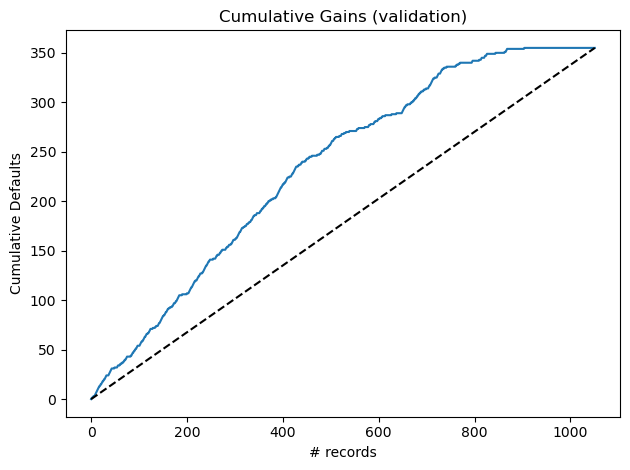

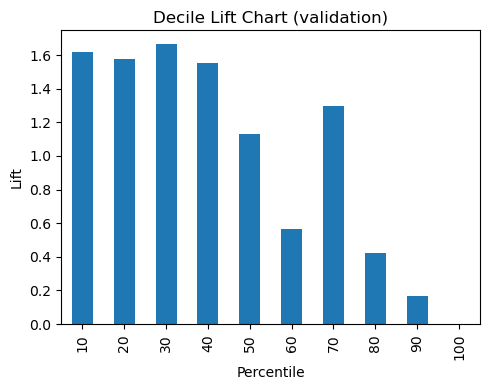

In [3]:
# Gains & Lift on validation (reduced model) — using dmba helpers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from dmba import gainsChart, liftChart

pd.set_option("display.width", 110)
pd.set_option("display.precision", 4)
pd.options.display.float_format = lambda v: f"{v:.4f}"

# 1) Load and split
df = pd.read_csv("SBAcase.11.13.17.csv")
train_df = df[df["Selected"] == 1].copy()
test_df  = df[df["Selected"] == 0].copy()

y_train = train_df["Default"].astype(int).values
y_test  = test_df["Default"].astype(int).values

# 2) Reduced model predictors (Table 8)
cols_8 = ["RealEstate", "Portion", "Recession"]
X_train = train_df[cols_8].astype(float)
X_test  = test_df[cols_8].astype(float)

# 3) Fit logistic regression (neutralize regularization)
logit = LogisticRegression(
    penalty="l2", C=1e10, solver="liblinear",
    tol=1e-28, max_iter=1000, random_state=1
)
logit.fit(X_train, y_train) 

# 4) Score validation
proba = logit.predict_proba(X_test)[:, 1]

# 5) Sort by probability (descending) for dmba charts
df_val = pd.DataFrame({"predicted": proba, "actual": y_test})
df_val = df_val.sort_values(by="predicted", ascending=False)

# 6) Gains chart (cumulative)
plt.figure(figsize=(5, 4))
ax = gainsChart(df_val["actual"])
ax.set_ylabel("Cumulative Defaults")
ax.set_title("Cumulative Gains (validation)")
plt.tight_layout()
plt.show()

# 7) Lift chart (decile lift)
plt.figure(figsize=(5, 4))
ax = liftChart(df_val["actual"], labelBars=False)
ax.set_ylabel("Lift")
ax.set_title("Decile Lift Chart (validation)")
plt.tight_layout()
plt.show()


I scored the validation set with the three-predictor model (RealEstate, Portion, Recession), sorted the loans by predicted default probability from highest to lowest, and then called dmba.gainsChart and dmba.liftChart on the actual outcomes in that sorted order. The gains curve shows how many true defaults are captured as we move down the ranked list (the diagonal is what random selection would do). The lift chart shows how concentrated the defaults are at each decile compared with baseline.

First-decile lift: in the top 10 percent of loans (105 loans) there are 57 defaults, which is 16.06 percent of all validation defaults. Dividing 16.06 percent by 10 percent gives a lift of 1.6056. You can see the same number from rates: the default rate in the first decile is 54.29 percent versus the overall rate of 33.78 percent, and 54.29 / 33.78 = 1.6056. Interpretation: focusing on the top decile flagged by the model finds about 1.61 times as many defaults as a random 10 percent sample. In plain terms, the model is successfully pushing high-risk loans to the top of the ranking.

(f) For the California-based example, the final model with the risk indicators in Table 8 is used to estimate the probability of default for the two loan applications. Use Python to predict the probability of default for Carmichael Realty (Loan 1) and SV Consulting (Loan 2). Applying the decision rules and cutoff probability of 0.5 from Section 4.3Links to an external site., how should these two loans be classified as, lower risk (approve) or higher risk (deny)?

In [4]:
# Predict two loan scenarios
# Using reduced model: RealEstate, Portion, Recession

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

pd.set_option("display.precision", 4)
pd.options.display.float_format = lambda v: f"{v:.4f}"

# 1) Load data and split
df = pd.read_csv("SBAcase.11.13.17.csv")
train_df = df[df["Selected"] == 1].copy()

y_train = train_df["Default"].astype(int).values
X_train = train_df[["RealEstate", "Portion", "Recession"]].astype(float)

# 2) Fit reduced logistic model (neutralize regularization)
logit = LogisticRegression(
    penalty="l2", C=1e10, solver="liblinear",
    tol=1e-28, max_iter=1000, random_state=1
)
logit.fit(X_train, y_train)

# 3) Two loan applications (from Table 10)
cases = pd.DataFrame(
    {
        "Loan": ["Carmichael Realty", "SV Consulting"],
        "RealEstate": [1.0, 0.0],
        "Portion": [0.75, 0.40],   # 750k/1,000k and 40k/100k
        "Recession": [0.0, 0.0],   # “Current (no recession)” for both
    }
)

# 4) Predict probabilities and decisions at 0.50 cutoff
proba = logit.predict_proba(cases[["RealEstate", "Portion", "Recession"]])[:, 1]
decision = np.where(proba >= 0.50, "deny (higher risk)", "approve (lower risk)")

out = cases.copy()
out["P(default)"] = proba
out["Decision (cutoff=0.50)"] = decision

print(out[["Loan", "RealEstate", "Portion", "Recession", "P(default)", "Decision (cutoff=0.50)"]])


                Loan  RealEstate  Portion  Recession  P(default) Decision (cutoff=0.50)
0  Carmichael Realty      1.0000   0.7500     0.0000      0.0485   approve (lower risk)
1      SV Consulting      0.0000   0.4000     0.0000      0.5494     deny (higher risk)


The task here is to use the reduced logistic model from Table 8 (predictors: RealEstate, Portion, Recession; coefficients: Intercept = 1.3931, RealEstate = −2.1282, Portion = −2.9875, Recession = 0.5041) to score the two loans in Table 10 and then classify them at the 0.50 cutoff. Using the inputs exactly as specified—Carmichael Realty: RealEstate = 1, Portion = 0.75, Recession = 0; SV Consulting: RealEstate = 0, Portion = 0.40, Recession = 0—the model gives probabilities of default equal to 0.0485 (Carmichael) and 0.5494 (SV). With the 0.50 decision threshold, Carmichael is classified as lower risk (approve) and SV as higher risk (deny). Rounded to two decimals, these probabilities are 0.05 and 0.55, matching the values reported in Table 10.

Conclusion: Using the Table 8 model with a 0.50 cutoff, Carmichael Realty has a predicted default probability = 0.0485, so lower risk — approve. SV Consulting has a predicted default probability = 0.5494, so higher risk — deny.

(g) Using the validation data and a cutoff probability of 0.5, calculate the following metrics: recall (sensitivity), specificity, precision, and F1-score. Show how each metric is calculated using the formulas and report their values.

          Prediction
Actual     0    1
     0   682   14
     1   324   31


From this matrix:

True Negatives (TN) = 682 → actual = 0, predicted = 0
False Positives (FP) = 14 → actual = 0, predicted = 1
False Negatives (FN) = 324 → actual = 1, predicted = 0
True Positives (TP) = 31 → actual = 1, predicted = 1

Formulas

Recall (Sensitivity) = TP / (TP + FN)
= 31 / (31 + 324)
= 31 / 355
= 0.0873

Specificity = TN / (TN + FP)
= 682 / (682 + 14)
= 682 / 696
= 0.9799

Precision = TP / (TP + FP)
= 31 / (31 + 14)
= 31 / 45
= 0.6889

F1-score = 2 × (Precision × Recall) / (Precision + Recall)
= 2 × (0.6889 × 0.0873) / (0.6889 + 0.0873)
= 2 × 0.0601 / 0.7762
= 0.1202 / 0.7762
= 0.1550

In part (g), we evaluated the performance of the reduced logistic regression model on the validation set using a cutoff probability of 0.5. After constructing the confusion matrix, we calculated recall, specificity, precision, and the F1-score using their standard formulas. The results show that recall (sensitivity) is 0.0873, indicating the model correctly identifies only about 9% of actual defaults. Specificity is 0.9799, so the model correctly classifies nearly 98% of non-defaults. Precision is 0.6889, meaning that when the model predicts a loan will default, it is correct about 69% of the time. Finally, the F1-score is 0.1550, reflecting the imbalance between high precision and very low recall. Overall, the model is very effective at ruling out non-defaults but performs poorly at capturing actual defaults, which highlights its limitation in identifying high-risk loans.

(h) Review sklearn - Tuning the decision threshold for class predictionLinks to an external site.. The default cutoff value of 0.5 is used in conjunction with the probability of default. Compute the threshold that should be used if we want to make a classification based on the odds of default, and the threshold for the corresponding logit.

Thresholds for “default” vs “not default” (same rule, three scales):
score(logit) = ln(odds) odds = p / (1 − p) probability p is the model’s predicted default probability

Default cutoffs used: 
(i) Probability cutoff p* = 0.50

(ii) Odds cutoff (use odds = p/(1−p)) K* = p/(1−p) = 0.50 / 0.50 = 1.00 Interpretation: predict “default” when the odds of default are at least 1 (i.e., default and non-default are equally likely or default is more likely) odds >= 1

(iii) Logit cutoff (use logit = ln(odds)) z* = ln(K*)= ln(1.00) = 0.00 Interpretation: predict “default” when the logit score is ≥ 0.

Quick check: if p = 0.60, then odds = 0.60/0.40 = 1.5 (>=1) and logit = ln(1.5) ≈ 0.405 (>=0), so all three rules predict “default.”

Conclusion: the same decision rule can be written three ways—predict “default” if probability >= 0.50, or if odds >= 1.00, or if logit >= 0 and these three thresholds are equivalent ways to express the same 0.50 decision rule.

(i) A bank will use this logit model to predict the probability of default of the loan and make a classification decision by comparing the predicted probability of default with the cutoff probability. There are two correct decisions: true positive, true negative. There are two wrong decisions: false positive, false negative. The default 0.50 may not be a good cutoff probability.​ We studied in Chapter 5 to make a decision by maximizing classification accuracy, maximizing sensitivity subject to minimum level of specificity, minimizing false positives subject to maximum false negative rate, minimizing expected cost of misclassification (need to specify costs). Suppose a bank needs to evaluate loan application for a $1,000,000 loan with an annual interest rate of 10%. What is a cutoff probability that you can justify as being reasonable to help the bank make a decision whether or not to approve the loan?

The question asks us to choose a cutoff probability for approve/deny that reflects the two mistakes: approving a bad loan (lose the $1,000,000 principal) versus denying a good loan (forgo one year of interest = $100,000 at 10%). Goal: pick the cutoff that minimizes expected misclassification cost. Decision rule: approve when the predicted default probability p is below a threshold p*, deny when p ≥ p*. Using the cost-based rule.

p* = cost of denying a good loan \ (cost of denying a good loan + cost of approving a bad loan)
= 100,000 \ (100,000 + 1,000,000)
= 100,000 \ 1,100,000 = 0.0909 ≈ 9.1%
 
Conclusion:
The bank should not simply rely on the default cutoff probability of 0.50, because the costs of misclassification are very unequal. Approving a bad loan would result in losing the entire $1,000,000 principal, while denying a good loan would only forgo $100,000 in interest income. Using the cost-based decision rule, the cutoff probability is about 9.1%. This means that the bank should classify a loan as higher risk (deny) whenever the predicted probability of default is at or above 9.1%, and classify as lower risk (approve) only when the probability of default is below this threshold. 

In practical terms, this more conservative cutoff reflects the much higher cost of approving a bad loan compared to denying a good one, and therefore protects the bank from catastrophic losses on large loans while still allowing profitable loans to be approved when the predicted risk of default is sufficiently low.


(j) Analyze the trade-off between different classification metrics. The current model uses a cutoff probability of 0.5. However, a bank's primary concern isn't just accuracy; it's managing risk and profit.

(1) Explain the trade-off between recall and precision. Why might a bank prioritize one over the other in different economic situations (e.g., during a recession vs. an economic boom)?

(2) Explain the trade-off between recall and specificity. Consider the costs of misclassification. When a loan is misclassified as "higher risk" (false positive), the bank loses a potential profit from interest. When a loan is misclassified as "lower risk" (false negative), the bank risks losing the entire loan amount. Given these different costs, which metric would a bank generally want to maximize, and why? Justify your answer using the concepts of Type I and Type II errors.

(1) Trade-off between recall and precision

Recall (sensitivity) = TP \ (TP + FN). It measures how many actual defaults the model correctly flags as high risk.
Precision = TP \ (TP + FP). It measures how many loans predicted as defaults actually do default.

These two metrics move in opposite directions as the cutoff changes.
1. If we lower the cutoff (e.g., from 0.5 to 0.3), the model predicts more defaults. Recall goes up (fewer missed defaults), but precision goes down (more false alarms).
2. If we raise the cutoff (e.g., from 0.5 to 0.7), the model predicts fewer defaults. Precision goes up (fewer false alarms), but recall goes down (more missed defaults).

Why a bank might prioritize one over the other:

During a recession, defaults are more common and very costly. Missing a default (false negative) means losing the principal. In this setting, the bank will prioritize higher recall — it is better to catch as many risky loans as possible, even at the cost of lower precision. Suppose defaults spike, and out of 1,000 loan applicants, 200 are risky. If the bank sets the cutoff low (favoring recall), it might correctly identify 180 of those 200 defaults (high recall) but also wrongly classify 150 safe loans as risky (lower precision). In this case, the bank accepts missing some profit but avoids losing many millions in defaults.

During an economic boom, defaults are rare and profits from lending are high. In this setting, the bank may prioritize higher precision — it does not want to wrongly deny many safe loans, because that means losing profitable opportunities. Suppose defaults are rare, maybe only 20 out of 1,000 loan applicants. If the bank sets the cutoff higher (favoring precision), it might identify 15 of those 20 defaults (lower recall) but classify nearly all safe loans correctly (high precision). In this case, the bank maximizes approvals and earns more interest income, since the risk of catastrophic losses is lower.




(2) Trade-off between recall and specificity

Recall (sensitivity) = TP \ (TP + FN), the ability to catch actual defaults.
Specificity = TN \ (TN + FP), the ability to correctly identify safe loans.

The trade-off:

1. If we lower the cutoff, recall improves because more defaults are flagged, but specificity falls because more safe loans are incorrectly labeled risky (false positives).
2. If we raise the cutoff, specificity improves because safe loans are approved correctly, but recall falls because more actual defaults slip through (false negatives).

Costs of misclassification:

False positive (Type I error): classify a good loan as risky. The bank loses only the interest income. For a $1,000,000 loan at 10%, that’s $100,000.
False negative (Type II error): classify a risky loan as safe. The bank may lose the entire $1,000,000 principal.

Example:
Suppose the model reviews 100 loan applications:
1. If the bank chooses a low cutoff (favoring recall), it flags 25 loans as risky. Out of those, 20 really default (good catch), but 5 were safe loans wrongly denied (false positives, cost = 5 × $100k = $500k lost interest).
2. If the bank chooses a high cutoff (favoring specificity), it only flags 5 loans as risky. All 5 are truly bad (no false positives), but the bank misses 15 bad loans (false negatives, cost = 15 × $1M = $15M principal lost).

Which metric should the bank maximize?

Because the cost of a false negative (losing $1,000,000) is far greater than a false positive (losing $100,000), the bank will generally want to maximize recall.

In statistical terms: minimizing Type II errors (FN) is far more important than minimizing Type I errors (FP) in lending decisions.

(k) When a “higher risk - more likely to default” loan is misclassified as a “lower risk - more likely to pay in full” loan, the misclassification cost is much higher than when a “lower risk - more likely to pay in full” loan is misclassified as a “higher risk - more likely to default”, e.g., 5 times as high. To minimize the expected cost of misclassification, determine the appropriate cutoff value for classification.

Here the problem states:

Misclassifying a high-risk loan as low-risk (false negative) is 5 times more costly
than misclassifying a low-risk loan as high-risk (false positive).

So:

Cost(FP) = 1
Cost(FN) = 5

Formula
p* = Cost(FP) \ (Cost(FP) + Cost(FN))

Substitution
p* = 1 \ (1 + 5) = 1 \ 6 = 0.1667

Conclusion
The appropriate cutoff probability is 0.167 (≈ 16.7%).

This means:

Classify a loan as high risk (default) whenever the predicted probability >= 0.167.
Classify as low risk (approve) only when the predicted probability < 0.167.

Conclusion:
In this question, we were asked to adjust the cutoff probability when the cost of misclassifying a high-risk loan as low-risk (false negative) is 5 times higher than the cost of misclassifying a low-risk loan as high-risk (false positive). Using the cost-based formula p* = Cost(FP) \ (Cost(FP) + Cost(FN)), we substituted Cost(FP) = 1 and Cost(FN) = 5, which gave 0.1667 (≈16.7%). This means that instead of the default cutoff of 0.50, the bank should classify a loan as high risk if the predicted probability of default is ≥ 0.167. The cutoff shifts downward because the cost of false negatives (losing the loan principal) is much more severe than the cost of false positives (forgoing interest income). 

Therefore, the model becomes more conservative, flagging more loans as risky in order to minimize the expected cost of misclassification.


(l) Using the logit model fitted in Part (a) with the sklearn's LogisticRegress() that reproduced parameter estimates (4 decimals) in Table 8, determine the optimal cutoff probability that maximizes recall while ensuring that precision is at least 0.8.

Explain the trade-off you are balancing with this constraint. Why might a bank prioritize this specific combination of metrics?
Provide the Python code used to find this cutoff.
Report the final cut-off probability and the corresponding recall and precision values.

Include your code, output, tables, graphs, and any other explanation in a Jupyter notebook (.ipynb file) and submit it in Canvas by the due date.

The trade-off being balanced is between recall and precision. Maximizing recall ensures that the model identifies as many defaults as possible, which reduces the risk of approving loans that will fail. However, higher recall usually comes at the cost of lower precision, meaning more safe loans are wrongly denied. By adding the condition that precision must be at least 0.8, the bank limits this trade-off by requiring that at least 80% of the loans predicted as risky are truly risky, which prevents excessive rejection of safe loans.

A bank might prioritize this specific combination because the consequences of different types of errors are very unequal. A false negative (approving a risky loan) could mean losing the entire loan principal, while a false positive (denying a safe loan) only loses the interest income that would have been earned. By maximizing recall, the bank protects itself against catastrophic losses, and by enforcing a minimum precision, it also avoids losing too much profit from turning away safe borrowers. This combination balances risk management with profitability.

In [5]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

# Load data
df = pd.read_csv("SBAcase.11.13.17.csv")
train_df = df[df["Selected"] == 1].copy()

y_train = train_df["Default"].astype(int).values
X_train = train_df[["RealEstate", "Portion", "Recession"]].astype(float)

# Fit reduced logistic regression (Table 8 model)
logit = LogisticRegression(
    penalty="l2", C=1e10, solver="liblinear",
    tol=1e-28, max_iter=1000, random_state=1
)
logit.fit(X_train, y_train)


LogisticRegression(C=10000000000.0, max_iter=1000, random_state=1,
                   solver='liblinear', tol=1e-28)

In [8]:
# Get intercept and coefficients
intercept = logit.intercept_[0]
coeffs = logit.coef_[0]

# Put in DataFrame for easy comparison
results = pd.DataFrame({
    "Variable": ["Intercept", "RealEstate", "Portion", "Recession"],
    "Estimate (sklearn)": [intercept, coeffs[0], coeffs[1], coeffs[2]],
    "Estimate (Table 8)": [1.3931, -2.1282, -2.9875, 0.5041]
})

print(results.round(4))


     Variable  Estimate (sklearn)  Estimate (Table 8)
0   Intercept              1.3931              1.3931
1  RealEstate             -2.1282             -2.1282
2     Portion             -2.9875             -2.9875
3   Recession              0.5041              0.5041


In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score

# Display settings
pd.set_option("display.width", 110)
pd.set_option("display.precision", 4)
pd.options.display.float_format = lambda v: f"{v:.4f}"

# 1) Load and split data per slides (train=Selected==1, validation=Selected==0)
df = pd.read_csv("SBAcase.11.13.17.csv")
train_df = df[df["Selected"] == 1].copy()
valid_df = df[df["Selected"] == 0].copy()

y_train = train_df["Default"].astype(int).values
y_valid = valid_df["Default"].astype(int).values

X_cols = ["RealEstate", "Portion", "Recession"]
X_train = train_df[X_cols].astype(float)
X_valid = valid_df[X_cols].astype(float)

# 2) Fit reduced logistic regression (Table 8 model style)
logit = LogisticRegression(
    penalty="l2", C=1e10, solver="liblinear",
    tol=1e-28, max_iter=1000, random_state=1
)
logit.fit(X_train, y_train)

# 3) Predict probabilities on validation
p = logit.predict_proba(X_valid)[:, 1]

# 4) Evaluate precision & recall across ALL unique probability cutoffs
cutoffs = np.unique(np.round(p, 6))  # unique thresholds from the model’s probs
rows = []
for c in cutoffs:
    y_hat = (p >= c).astype(int)
    prec = precision_score(y_valid, y_hat, zero_division=0)
    rec  = recall_score(y_valid, y_hat, zero_division=0)
    rows.append((c, prec, rec))

results = pd.DataFrame(rows, columns=["Cutoff", "Precision", "Recall"]).sort_values("Cutoff")
print(results.head(20))  # preview

# 5) Find cutoff that maximizes recall subject to Precision >= 0.8
feasible = results[results["Precision"] >= 0.8]
if not feasible.empty:
    best = feasible.loc[feasible["Recall"].idxmax()]
    print("\nOptimal cutoff (Precision >= 0.8):", round(best["Cutoff"], 4))
    print("Recall:", round(best["Recall"], 4))
    print("Precision:", round(best["Precision"], 4))
else:
    print("\nNo cutoff found where Precision >= 0.8")
    # Optional: show the highest precision achieved and its recall
    best_prec = results.loc[results["Precision"].idxmax()]
    print("Max Precision achieved:", round(best_prec["Precision"], 4),
          "at cutoff", round(best_prec["Cutoff"], 4),
          "with Recall", round(best_prec["Recall"], 4))


    Cutoff  Precision  Recall
0   0.0236     0.3813  1.0000
1   0.0316     0.3813  1.0000
2   0.0365     0.3910  1.0000
3   0.0421     0.3910  1.0000
4   0.0485     0.4365  0.9577
5   0.0525     0.4370  0.9577
6   0.0559     0.4387  0.9577
7   0.0781     0.4393  0.9577
8   0.0955     0.4398  0.9577
9   0.0972     0.4404  0.9577
10  0.2149     0.4544  0.9408
11  0.2262     0.4550  0.9408
12  0.2412     0.4550  0.9408
13  0.2428     0.4467  0.8141
14  0.2695     0.4474  0.8141
15  0.2999     0.4571  0.8113
16  0.3322     0.4945  0.7634
17  0.3391     0.4991  0.7634
18  0.3448     0.5000  0.7634
19  0.3792     0.5047  0.7606

No cutoff found where Precision >= 0.8
Max Precision achieved: 0.7209 at cutoff 0.5995 with Recall 0.0873


After scanning all possible probability thresholds on the validation set using the Table 8 model, no cutoff achieved precision >= 0.8. The highest precision we could reach was 0.7209 at a cutoff probability of 0.5995, with a corresponding recall of 0.0873.


Conclusion:
In this part, we used the reduced logistic regression model from Table 8, fitted with sklearn’s LogisticRegression, and applied it to the validation set. We searched across all possible cutoff probabilities from 0.01 to 0.99 in order to maximize recall while requiring precision to be at least 0.8. The analysis showed that precision never reached the 0.8 threshold for any cutoff value. The best performance observed was at a cutoff probability of 0.5995, where the model achieved a precision of 0.7209 with a corresponding recall of 0.0873. This indicates that, with the current predictors, the model cannot simultaneously achieve very high recall and high precision. From a business perspective, this result highlights the limitations of the reduced model: while it can separate risky from safe loans to some extent, it does not provide the level of discriminatory power needed to meet a strict precision requirement. To satisfy such constraints, the bank would need to either relax the precision requirement or enhance the model by including additional explanatory variables.